In [6]:
# ── Phase 1: Data Loading ──────────────────────────────────────────

# Import core libraries
import pandas as pd        # DataFrames — our main data table
import numpy as np         # Numerical operations
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns      # Statistical visualisation

# Suppress minor warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# ── Load the dataset ───────────────────────────────────────────────
df = pd.read_csv('C:/Users/ruhig/OneDrive/Desktop/PROJECTS/Customer_Churn_Prediction/telco.csv')

# Quick sanity check: shape tells us (rows, columns)
print(f"Dataset shape: {df.shape}")          # → (7043, 21)
print("Column names:")
(df.columns.tolist())

# Preview the first 5 rows
df.head()

Dataset shape: (7043, 50)
Column names:


,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [7]:
print(df.columns.tolist())
print("\n")
print(df.dtypes)
print("\n")
print(df.shape)

['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents', 'Country', 'State', 'City', 'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label', 'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason']


Customer ID                           object
Gender                                object
Age                                    int64
U

In [8]:
# ── Phase 2: Data Cleaning ─────────────────────────────────────────

# Step 2a — Drop columns that cause data leakage
# These columns REVEAL churn outcome — model would cheat if we kept them
leakage_cols = [
    'Churn Score',        # directly derived from churn
    'Churn Category',     # only filled when customer churned
    'Churn Reason',       # only filled when customer churned
    'Customer Status',    # literally says "Churned" or "Stayed"
    'CLTV',               # calculated using churn probability
]

# Step 2b — Drop geographic/ID columns with no predictive value
irrelevant_cols = [
    'Customer ID',        # unique identifier, not a feature
    'Country',            # everyone is USA in this dataset
    'State',              # everyone is California
    'City',               # too granular, causes noise
    'Zip Code',           # too granular
    'Latitude',           # geographic noise
    'Longitude',          # geographic noise
    'Quarter',            # all same value in this dataset
]

df.drop(columns=leakage_cols + irrelevant_cols, inplace=True)
print(f"Columns after dropping: {df.shape[1]}")  # → 33 columns

# Step 2c — Encode target column: 'Yes' → 1, 'No' → 0
df['Churn Label'] = df['Churn Label'].map({'Yes': 1, 'No': 0})

# Step 2d — Check for missing values
print(f"\nMissing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Step 2e — Drop any rows with missing values (very few if any)
df.dropna(inplace=True)
print(f"\nFinal dataset shape: {df.shape}")
print(f"\nChurn distribution:")
print(df['Churn Label'].value_counts())
print(f"\nChurn rate: {df['Churn Label'].mean()*100:.1f}%")

Columns after dropping: 37

Missing values per column:
Offer            3877
Internet Type    1526
dtype: int64

Final dataset shape: (2493, 37)

Churn distribution:
Churn Label
0    1736
1     757
Name: count, dtype: int64

Churn rate: 30.4%


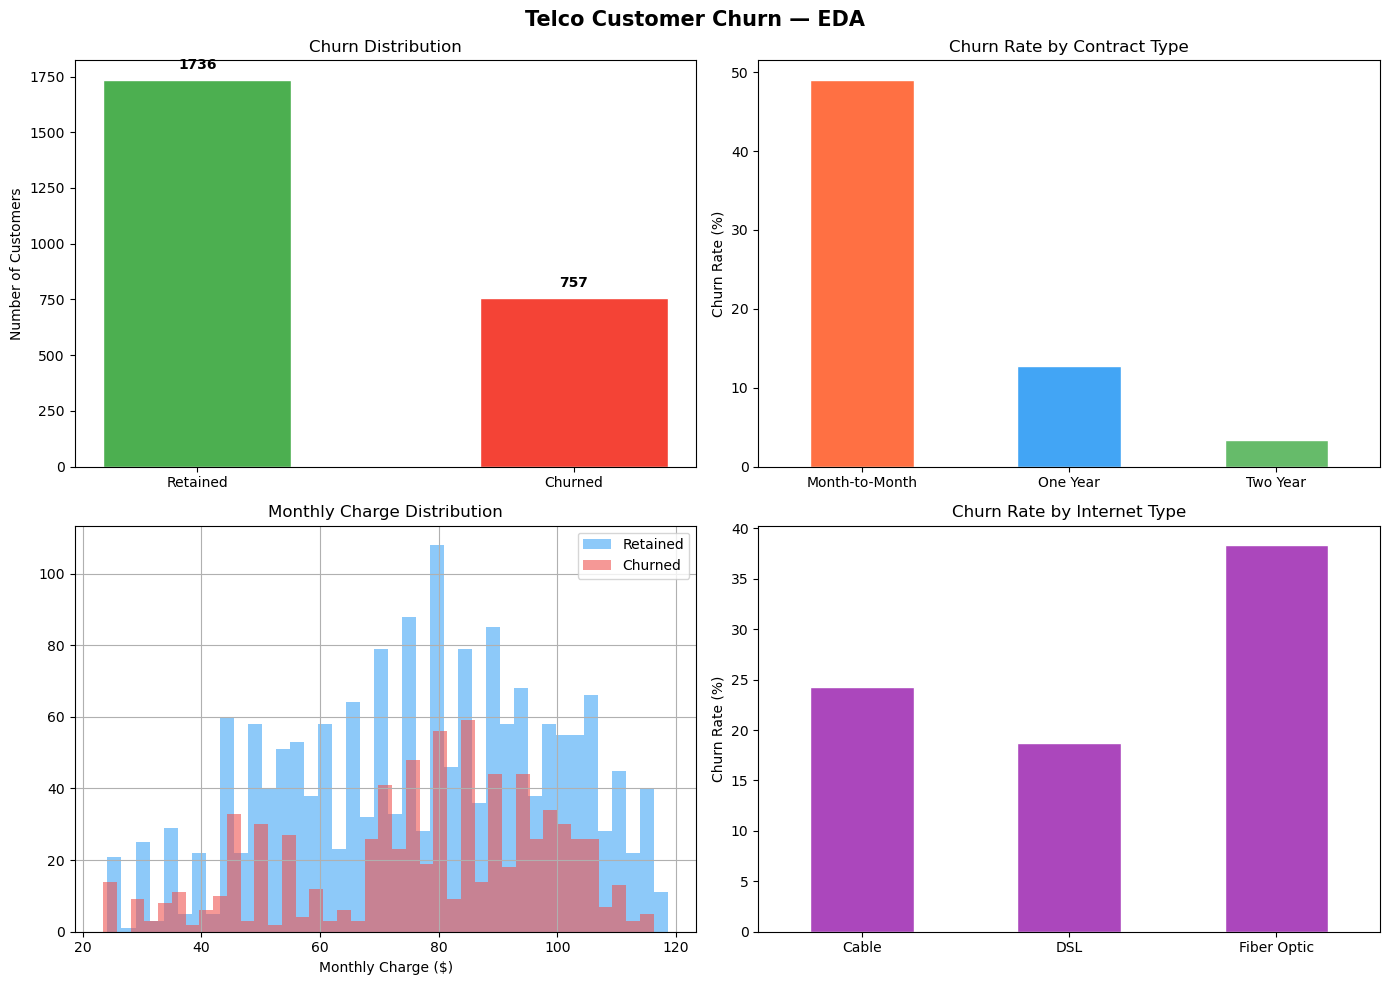

In [9]:
# ── Phase 3: Exploratory Data Analysis ────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Telco Customer Churn — EDA', fontsize=15, fontweight='bold')

# ── Plot 1: Churn distribution ─────────────────────────────────────
churn_counts = df['Churn Label'].value_counts()
axes[0,0].bar(['Retained', 'Churned'], churn_counts,
               color=['#4CAF50', '#F44336'], edgecolor='white', width=0.5)
axes[0,0].set_title('Churn Distribution')
axes[0,0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts):
    axes[0,0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# ── Plot 2: Churn rate by contract type ───────────────────────────
contract_churn = df.groupby('Contract')['Churn Label'].mean() * 100
contract_churn.plot(kind='bar', ax=axes[0,1],
                    color=['#FF7043','#42A5F5','#66BB6A'],
                    edgecolor='white', rot=0)
axes[0,1].set_title('Churn Rate by Contract Type')
axes[0,1].set_ylabel('Churn Rate (%)')
axes[0,1].set_xlabel('')

# ── Plot 3: Monthly charge distribution ───────────────────────────
df[df['Churn Label']==0]['Monthly Charge'].hist(
    bins=40, ax=axes[1,0], alpha=0.6, color='#42A5F5', label='Retained')
df[df['Churn Label']==1]['Monthly Charge'].hist(
    bins=40, ax=axes[1,0], alpha=0.6, color='#EF5350', label='Churned')
axes[1,0].set_title('Monthly Charge Distribution')
axes[1,0].set_xlabel('Monthly Charge ($)')
axes[1,0].legend()

# ── Plot 4: Churn rate by Internet Type ───────────────────────────
internet_churn = df.groupby('Internet Type')['Churn Label'].mean() * 100
internet_churn.plot(kind='bar', ax=axes[1,1],
                    color='#AB47BC', edgecolor='white', rot=0)
axes[1,1].set_title('Churn Rate by Internet Type')
axes[1,1].set_ylabel('Churn Rate (%)')
axes[1,1].set_xlabel('')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ── Phase 4: Preprocessing ─────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler
from imblearn.over_sampling import SMOTE

# Step 4a — Separate features and target
X = df.drop(columns=['Churn Label'])
y = df['Churn Label']

# Step 4b — One-Hot Encode all categorical (object) columns
X = pd.get_dummies(X, drop_first=True)
print(f"Features after encoding: {X.shape[1]}")

# Step 4c — Train/Test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Step 4d — Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit + transform on train only
X_test  = scaler.transform(X_test)       # transform test (no fit!)

# Step 4e — SMOTE to fix class imbalance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"\nBefore SMOTE: {dict(y_train.value_counts())}")
print(f"After  SMOTE: {dict(pd.Series(y_train_res).value_counts())}")

# ── Phase 5: Model Building ────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble     import RandomForestClassifier

# Model 1 — Logistic Regression (baseline)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_res, y_train_res)
print("✅ Logistic Regression trained")

# Model 2 — Random Forest
# n_jobs=1 instead of -1 to avoid Windows CPU detection bug
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=1        # ← changed from -1 to 1
)
rf_model.fit(X_train_res, y_train_res)
print("✅ Random Forest trained")

# Generate predictions on test set
lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

Features after encoding: 41

Before SMOTE: {0: np.int64(1389), 1: np.int64(605)}
After  SMOTE: {0: np.int64(1389), 1: np.int64(1389)}
✅ Logistic Regression trained
✅ Random Forest trained



  Logistic Regression
  Accuracy  : 0.9519
  Precision : 0.9103
  Recall    : 0.9342  ← KEY METRIC
  F1-Score  : 0.9221

  Classification Report:

              precision    recall  f1-score   support

    Retained       0.97      0.96      0.97       347
     Churned       0.91      0.93      0.92       152

    accuracy                           0.95       499
   macro avg       0.94      0.95      0.94       499
weighted avg       0.95      0.95      0.95       499


  Random Forest
  Accuracy  : 0.9299
  Precision : 0.8980
  Recall    : 0.8684  ← KEY METRIC
  F1-Score  : 0.8829

  Classification Report:

              precision    recall  f1-score   support

    Retained       0.94      0.96      0.95       347
     Churned       0.90      0.87      0.88       152

    accuracy                           0.93       499
   macro avg       0.92      0.91      0.92       499
weighted avg       0.93      0.93      0.93       499



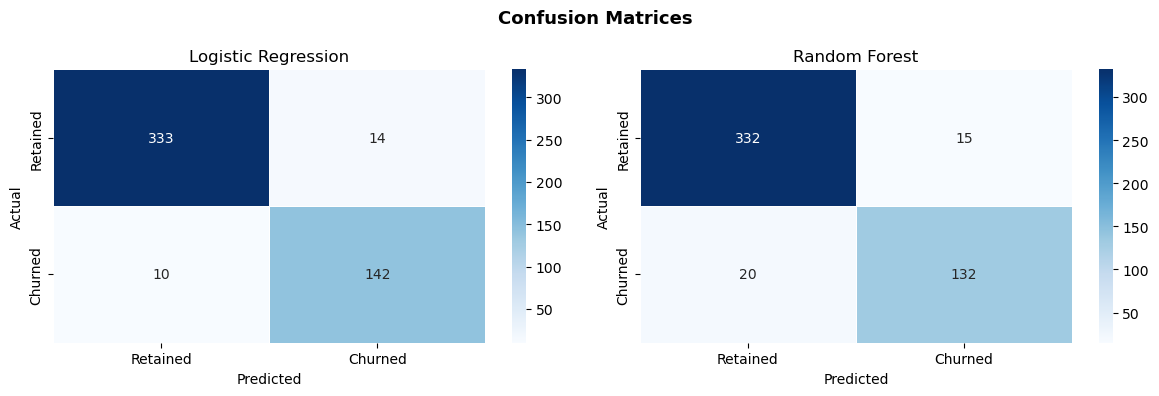

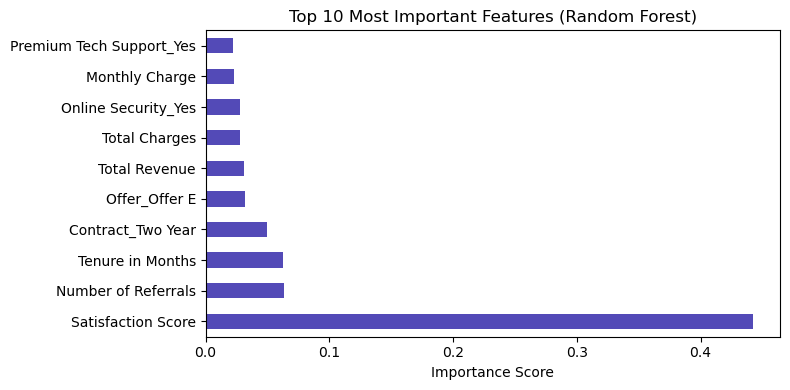

In [12]:
# ── Phase 6: Model Evaluation ──────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

def evaluate_model(name, y_true, y_pred):
    print(f"\n{'='*52}")
    print(f"  {name}")
    print(f"{'='*52}")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred):.4f}  ← KEY METRIC")
    print(f"  F1-Score  : {f1_score(y_true, y_pred):.4f}")
    print(f"\n  Classification Report:\n")
    print(classification_report(y_true, y_pred,
          target_names=['Retained', 'Churned']))

evaluate_model("Logistic Regression", y_test, lr_pred)
evaluate_model("Random Forest",       y_test, rf_pred)

# ── Confusion Matrices ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, pred) in zip(axes, [
        ("Logistic Regression", lr_pred),
        ("Random Forest",       rf_pred)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues', linewidths=0.5,
                xticklabels=['Retained', 'Churned'],
                yticklabels=['Retained', 'Churned'])
    ax.set_title(f'{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Top 10 Feature Importances (Random Forest) ────────────────────
feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=pd.get_dummies(
        df.drop(columns=['Churn Label']), drop_first=True
    ).columns
).nlargest(10)

feat_imp.plot(kind='barh', figsize=(8, 4), color='#534AB7')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()